In [3]:
# %pip install pandas
# %pip install matplotlib
# %pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
url="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/021/299/original/final_vg1_-_final_vg_(1).csv?1670840166"
data=pd.read_csv(url)
data.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,2061,1942,NES,1985.0,Shooter,Capcom,4.569217,3.033887,3.439352,1.991671,12.802935
1,9137,¡Shin Chan Flipa en colores!,DS,2007.0,Platform,505 Games,2.076955,1.493442,3.033887,0.394830,7.034163
2,14279,.hack: Sekai no Mukou ni + Versus,PS3,2012.0,Action,Namco Bandai Games,1.145709,1.762339,1.493442,0.408693,4.982552
3,8359,.hack//G.U. Vol.1//Rebirth,PS2,2006.0,Role-Playing,Namco Bandai Games,2.031986,1.389856,3.228043,0.394830,7.226880
4,7109,.hack//G.U. Vol.2//Reminisce,PS2,2006.0,Role-Playing,Namco Bandai Games,2.792725,2.592054,1.440483,1.493442,8.363113


In [5]:
data["Genre"].value_counts().index[:3]

Index(['Action', 'Sports', 'Misc'], dtype='str', name='Genre')

In [7]:
top3_pub = data['Publisher'].value_counts().index[:3]
top3_gen = data['Genre'].value_counts().index[:3]
top3_plat = data['Platform'].value_counts().index[:3]
top3_data=data.loc[(data["Publisher"].isin(top3_pub) )& (data["Genre"].isin(top3_gen)) & (data["Platform"].isin(top3_plat)) ]
display(top3_data)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
2,14279,.hack: Sekai no Mukou ni + Versus,PS3,2012.0,Action,Namco Bandai Games,1.145709,1.762339,1.493442,0.408693,4.982552
13,2742,[Prototype 2],PS3,2012.0,Action,Activision,3.978349,3.727034,0.848807,2.792725,11.447989
16,1604,[Prototype],PS3,2009.0,Action,Activision,4.569217,4.108402,1.187272,3.339269,13.181205
19,1741,007: Quantum of Solace,PS3,2008.0,Action,Activision,4.156030,4.346074,1.087977,3.390562,12.980643
21,4501,007: Quantum of Solace,PS2,2008.0,Action,Activision,3.228043,2.738800,2.585598,3.652926,11.780257
...,...,...,...,...,...,...,...,...,...,...,...
16438,14938,Yes! Precure 5 Go Go Zenin Shu Go! Dream Festival,DS,2008.0,Action,Namco Bandai Games,1.087977,0.592445,1.087977,0.394830,3.509168
16479,10979,Young Justice: Legacy,PS3,2013.0,Action,Namco Bandai Games,2.186589,1.087977,3.409089,0.394830,7.359902
16601,11802,ZhuZhu Pets: Quest for Zhu,DS,2011.0,Misc,Activision,2.340740,1.525543,3.103825,0.394830,7.372592
16636,9196,Zoobles! Spring to Life!,DS,2011.0,Misc,Activision,2.697415,1.087977,2.760718,0.394830,6.915540


In [ ]:
# Multivariate analysis 
# adding a third variable that may be categorical or numerical in to the existing variables
# the combinations that are mentioned are
# CCN
# CNN
# NNN

### NNC

**How can we visualize the correlation between NA and EU, but for different genres?**

Here, we have two numerical and one categorical variable!

- Numerical-Numerical $\rightarrow$ Scatter plot, need to add info about one categorical variable.
- Numerical-Categorical $\rightarrow$ Boxplot, need to add info about one numerical variable.

Let's ask two questions.
- Is it possible to add information about a continuous variable upon boxplots?
  - No
- Is it possible to add information about a categorical variable on scatterplot?
  - Yes (using colors)

<Axes: xlabel='NA_Sales', ylabel='EU_Sales'>

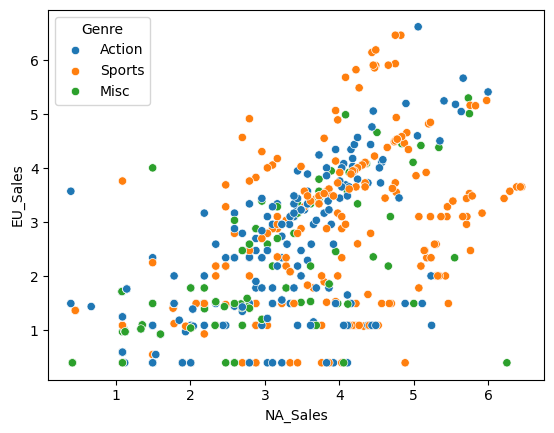

In [8]:
sns.scatterplot(data=top3_data,x="NA_Sales",y="EU_Sales",hue="Genre")

<Axes: xlabel='Genre', ylabel='NA_Sales'>

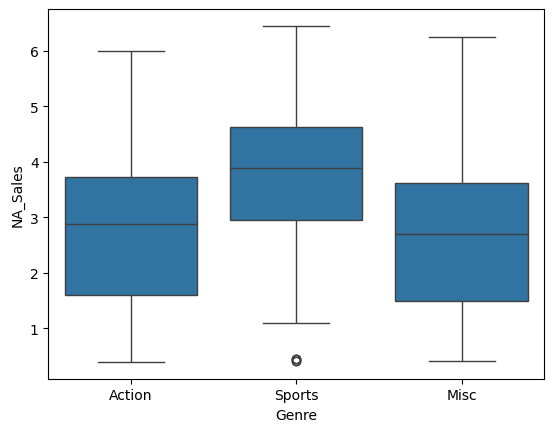

In [10]:
sns.boxplot(
    data=top3_data,
    x="Genre",
    y="NA_Sales"
)

| Feature                      | 📦 Box Plot                         | 🎯 Scatter Plot                  |
| ---------------------------- | ----------------------------------- | -------------------------------- |
| Purpose                      | Compare distributions across groups | Find relationships/correlation   |
| Variables                    | 1 Categorical + 1 Numerical         | 2 Numerical                      |
| Shows Individual Data Points | ❌ No (summarized)                   | ✅ Yes                            |
| Shows Median                 | ✅ Yes                               | ❌ No                             |
| Shows Quartiles (Q1, Q3)     | ✅ Yes                               | ❌ No                             |
| Shows Distribution Spread    | ✅ Yes                               | ❌ Limited                        |
| Shows Outliers               | ✅ Yes                               | ✅ Yes                            |
| Shows Correlation            | ❌ No                                | ✅ Yes                            |
| Best For                     | Comparing groups                    | Studying relationships           |
| Example                      | Genre vs Sales                      | NA Sales vs EU Sales             |
| Typical Question             | "How do groups differ?"             | "How are two variables related?" |


<Axes: xlabel='NA_Sales', ylabel='EU_Sales'>

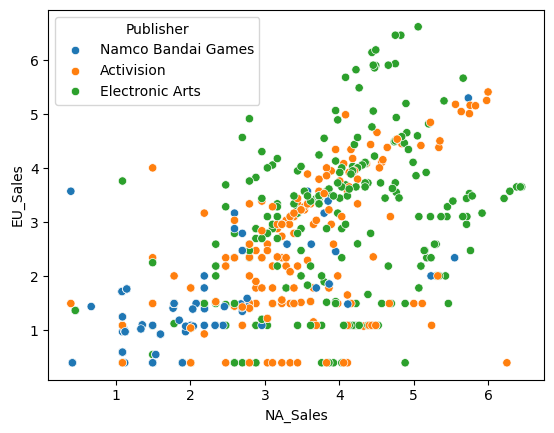

In [11]:
sns.scatterplot(data=top3_data,x="NA_Sales",y="EU_Sales",hue="Publisher")

Here as There is a Cluster between Activision it indicates that there is a strong correlation between NA and EU sales for the Activision Publisher. This means that as NA sales increase, EU sales also tend to increase for this genre, suggesting a positive relationship between the two variables in this context.

# 🎯 Scatter Plot Interpretation Cheat Sheet

## ↗ Positive Correlation

When **X increases, Y also increases**.

```text
Y ↑

10 |             •
 8 |         •
 6 |      •
 4 |   •
 2 | •
   +----------------→ X
```

**Interpretation:** Strong positive relationship

---

## ↘ Negative Correlation

When **X increases, Y decreases**.

```text
Y ↑

10 | •
 8 |    •
 6 |       •
 4 |          •
 2 |             •
   +----------------→ X
```

**Interpretation:** Strong negative relationship

---

## 🎲 No Correlation

No visible relationship between X and Y.

```text
Y ↑

10 |      •
 8 | •
 6 |           •
 4 |      •
 2 |   •
   +----------------→ X
```

**Interpretation:** Changes in X do not explain changes in Y

---

## 🔵🟢 Clusters

Natural groups exist in the data.

```text
Y ↑

10 |             🟢 🟢
 8 |           🟢 🟢

 4 | 🔵 🔵
 2 | 🔵 🔵

   +----------------→ X
```

**Interpretation:** Data contains distinct segments/groups

Examples:

* Different Genres
* Different Customer Types
* Different Species

---

## 🚨 Outlier

A point far away from the rest.

```text
Y ↑

10 |                    •
 8 |
 6 | • • • • •
 4 | • • • • •
 2 | • • • • •
   +----------------→ X
```

**Interpretation:** Unusual observation that deserves investigation

Examples:

* Fraudulent transaction
* Viral product
* Data entry error




### CCN

**How will you visualize the global sales for each publisher, but separated by genres?**

We have two categorical and one numerical data here!

- Categorical-Categorical $\rightarrow$ Stacked Bar plot, need to add info about one continuous feature.
- Categorical-Numerical $\rightarrow$ Boxplot, need to add categorical variable.

**Which one is easier and possible?**

We can add one categorical variable by “dodging” multiple boxplots.

<Axes: xlabel='Publisher', ylabel='Global_Sales'>

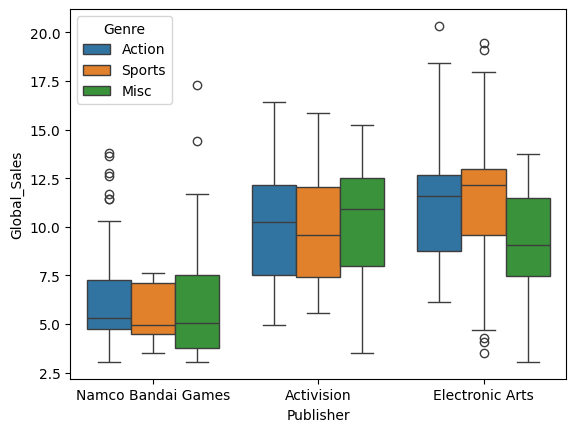

In [12]:
sns.boxplot(data=top3_data,x="Publisher",y="Global_Sales",hue="Genre")

In [ ]:
# This method adding two or more boxes beside each other is known as dodging


| Observation                                                | Evidence from Box Plot                                                           | How the Inference Was Made                                                                                                                    |
| ---------------------------------------------------------- | -------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------- |
| Namco has lower median sales across genres                 | The median lines inside Namco's boxes are lower than those of Activision and EA. | Compare the horizontal median lines for each genre across publishers. Lower median lines indicate lower typical sales.                        |
| EA Action is more spread than Activision Action            | EA's Action box and whiskers are taller than Activision's.                       | Compare the box heights (IQR) and whisker lengths. A larger box and longer whiskers indicate greater variability in sales.                    |
| Different publishers have different best-performing genres | The highest median line for each publisher occurs in a different genre.          | Within each publisher, identify the genre whose box has the highest median line. That genre has the highest typical sales for that publisher. |


### NNN

So far we have seen how NA and EU are correlated with each other.

But how can we compare the data when we have 3 numerical variables?

**How does rank affect the correlation between NA and EU Sales?**

We have used scatter plot for two numerical features.

We have two options here -

- Make a 3D Scatterplot
  - Good for 3D visualization, but tough to report/show in static setting.
- Add info about the 3rd feature on the 2D scatter plot itself.
  - Bubble Chart

<Axes: xlabel='NA_Sales', ylabel='EU_Sales'>

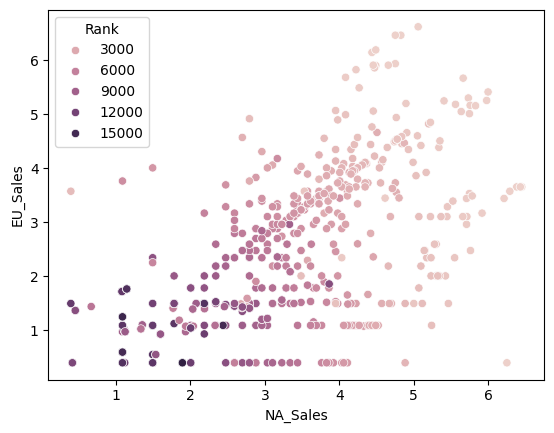

In [13]:
sns.scatterplot(data=top3_data,x="NA_Sales",y="EU_Sales",hue="Rank")

**Inferences:**

- Interestingly, we can notice that higher ranking games are actually on the lower scale of sales, while lower ranking games are high on the sales side. This suggests that there may be an inverse relationship between rank and sales, where higher-ranked games tend to have lower sales, and lower-ranked games tend to have higher sales. This could be due to various factors such as market saturation, competition, or consumer preferences.

## Joint Plot

- `jointplot()` draws a plot between two variables.
- It shows scatter plot, histogram and KDE plot in the same plot.

Let's check it out -

- We will take **`NA_Sales` as x-coordinates** and **`EU_Sales` as y-coordinates**.
- We can select from different values for parameter `kind and it will plot accordingly.
  - "scatter" | "kde" | "hist" | "hex" | "reg" | "resid"

- We will set the `kind` parameter to **'reg'** here.

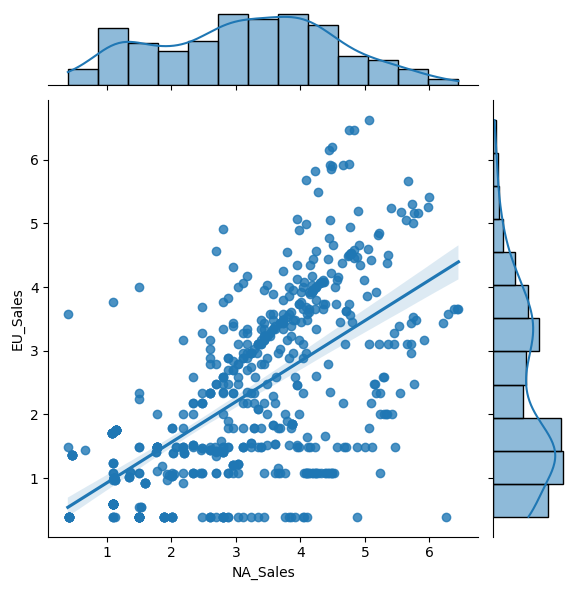

In [14]:
sns.jointplot(x="NA_Sales",y="EU_Sales",data=top3_data,kind="reg")

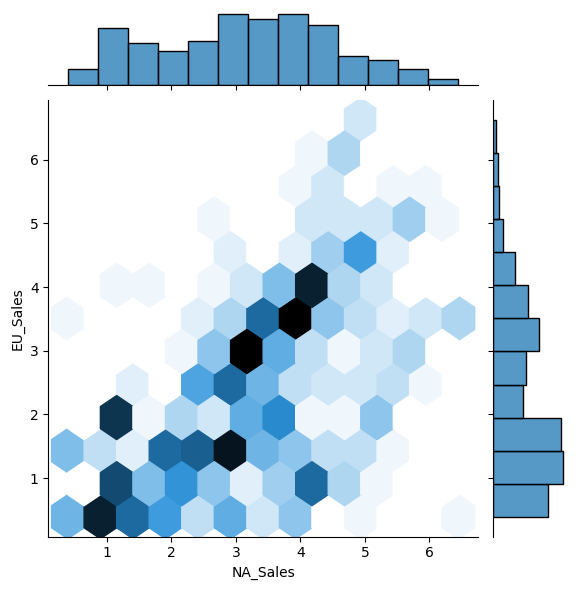

In [15]:
sns.jointplot(x="NA_Sales",y="EU_Sales",data=top3_data,kind="hex")

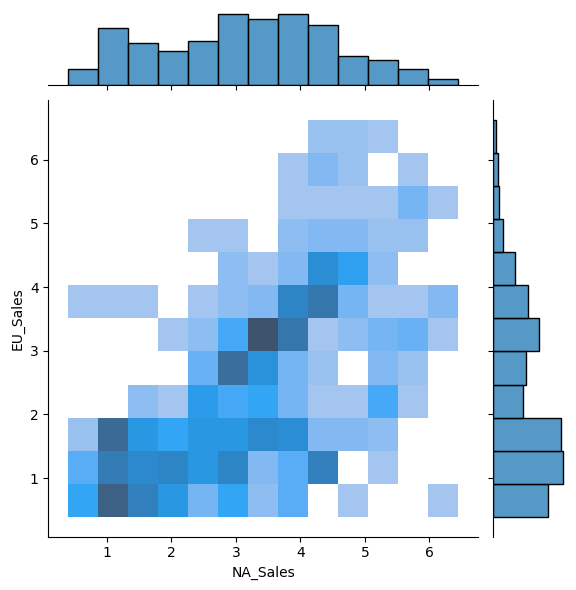

In [16]:
sns.jointplot(x="NA_Sales",y="EU_Sales",data=top3_data,kind="hist")

As we can see here,
- `jointplot` plots scatter plot, histogram and KDE plot in the same graph, when we set `kind=reg`.
- Scatter plot shows the **scattering of (`NA_Sales`, `EU_Sales`) pairs as (x, y) points**.
- Histogram and KDE plot show the separate distributions of `NA_Sales` and `EU_Sales` in the data.

**We can also add hue to Joint plot.**

Let's check how the 3 genres of games are distributed in terms of `NA_Sales` and `EU_Sales`.

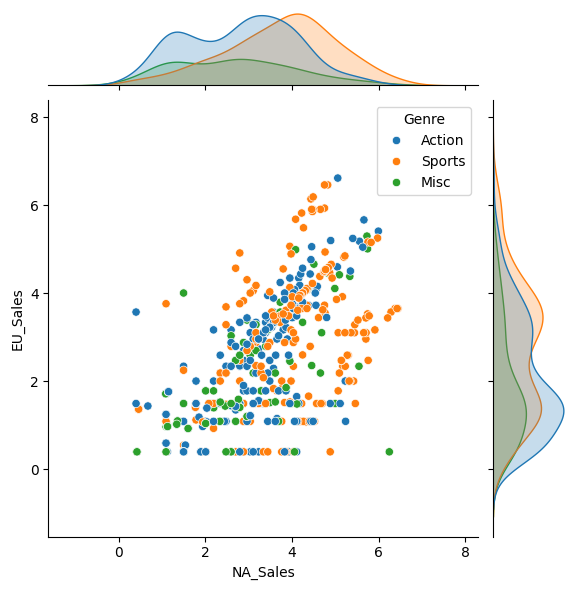

In [19]:
sns.jointplot(data=top3_data,x="NA_Sales",y="EU_Sales",hue="Genre")

# 🎨 Pair Plot Cheat Sheet

## What is a Pair Plot?

> **A matrix of scatter plots showing relationships between every pair of numerical variables.**

---

## Visual Structure

```text
              Age      Salary      Exp

Age          Hist       •••        •••

Salary       •••        Hist       •••

Exp          •••        •••        Hist
```

### Diagonal

```text
📊 Distribution

███
█████
███
```

Shows the distribution of each variable.

---

### Off-Diagonal

```text
      •
   •
 •
      •
         •
```

Shows relationships between pairs of variables.

---

## With Hue

```python
sns.pairplot(df, hue="Species")
```

```text
🔵 Setosa

🟢 Versicolor

🟡 Virginica
```

Helps identify clusters and class separation.

---

## What Can You Find?

| Insight                   | Pair Plot |
| ------------------------- | --------- |
| Correlation               | ✅         |
| Positive/Negative Trends  | ✅         |
| Outliers                  | ✅         |
| Clusters                  | ✅         |
| Class Separation          | ✅         |
| Distribution of Variables | ✅         |

---

## Memory Trick

```text
JointPlot
   ↓
One Relationship

Age ↔ Salary


PairPlot
   ↓
All Relationships

Age ↔ Salary
Age ↔ Experience
Salary ↔ Experience
...
```


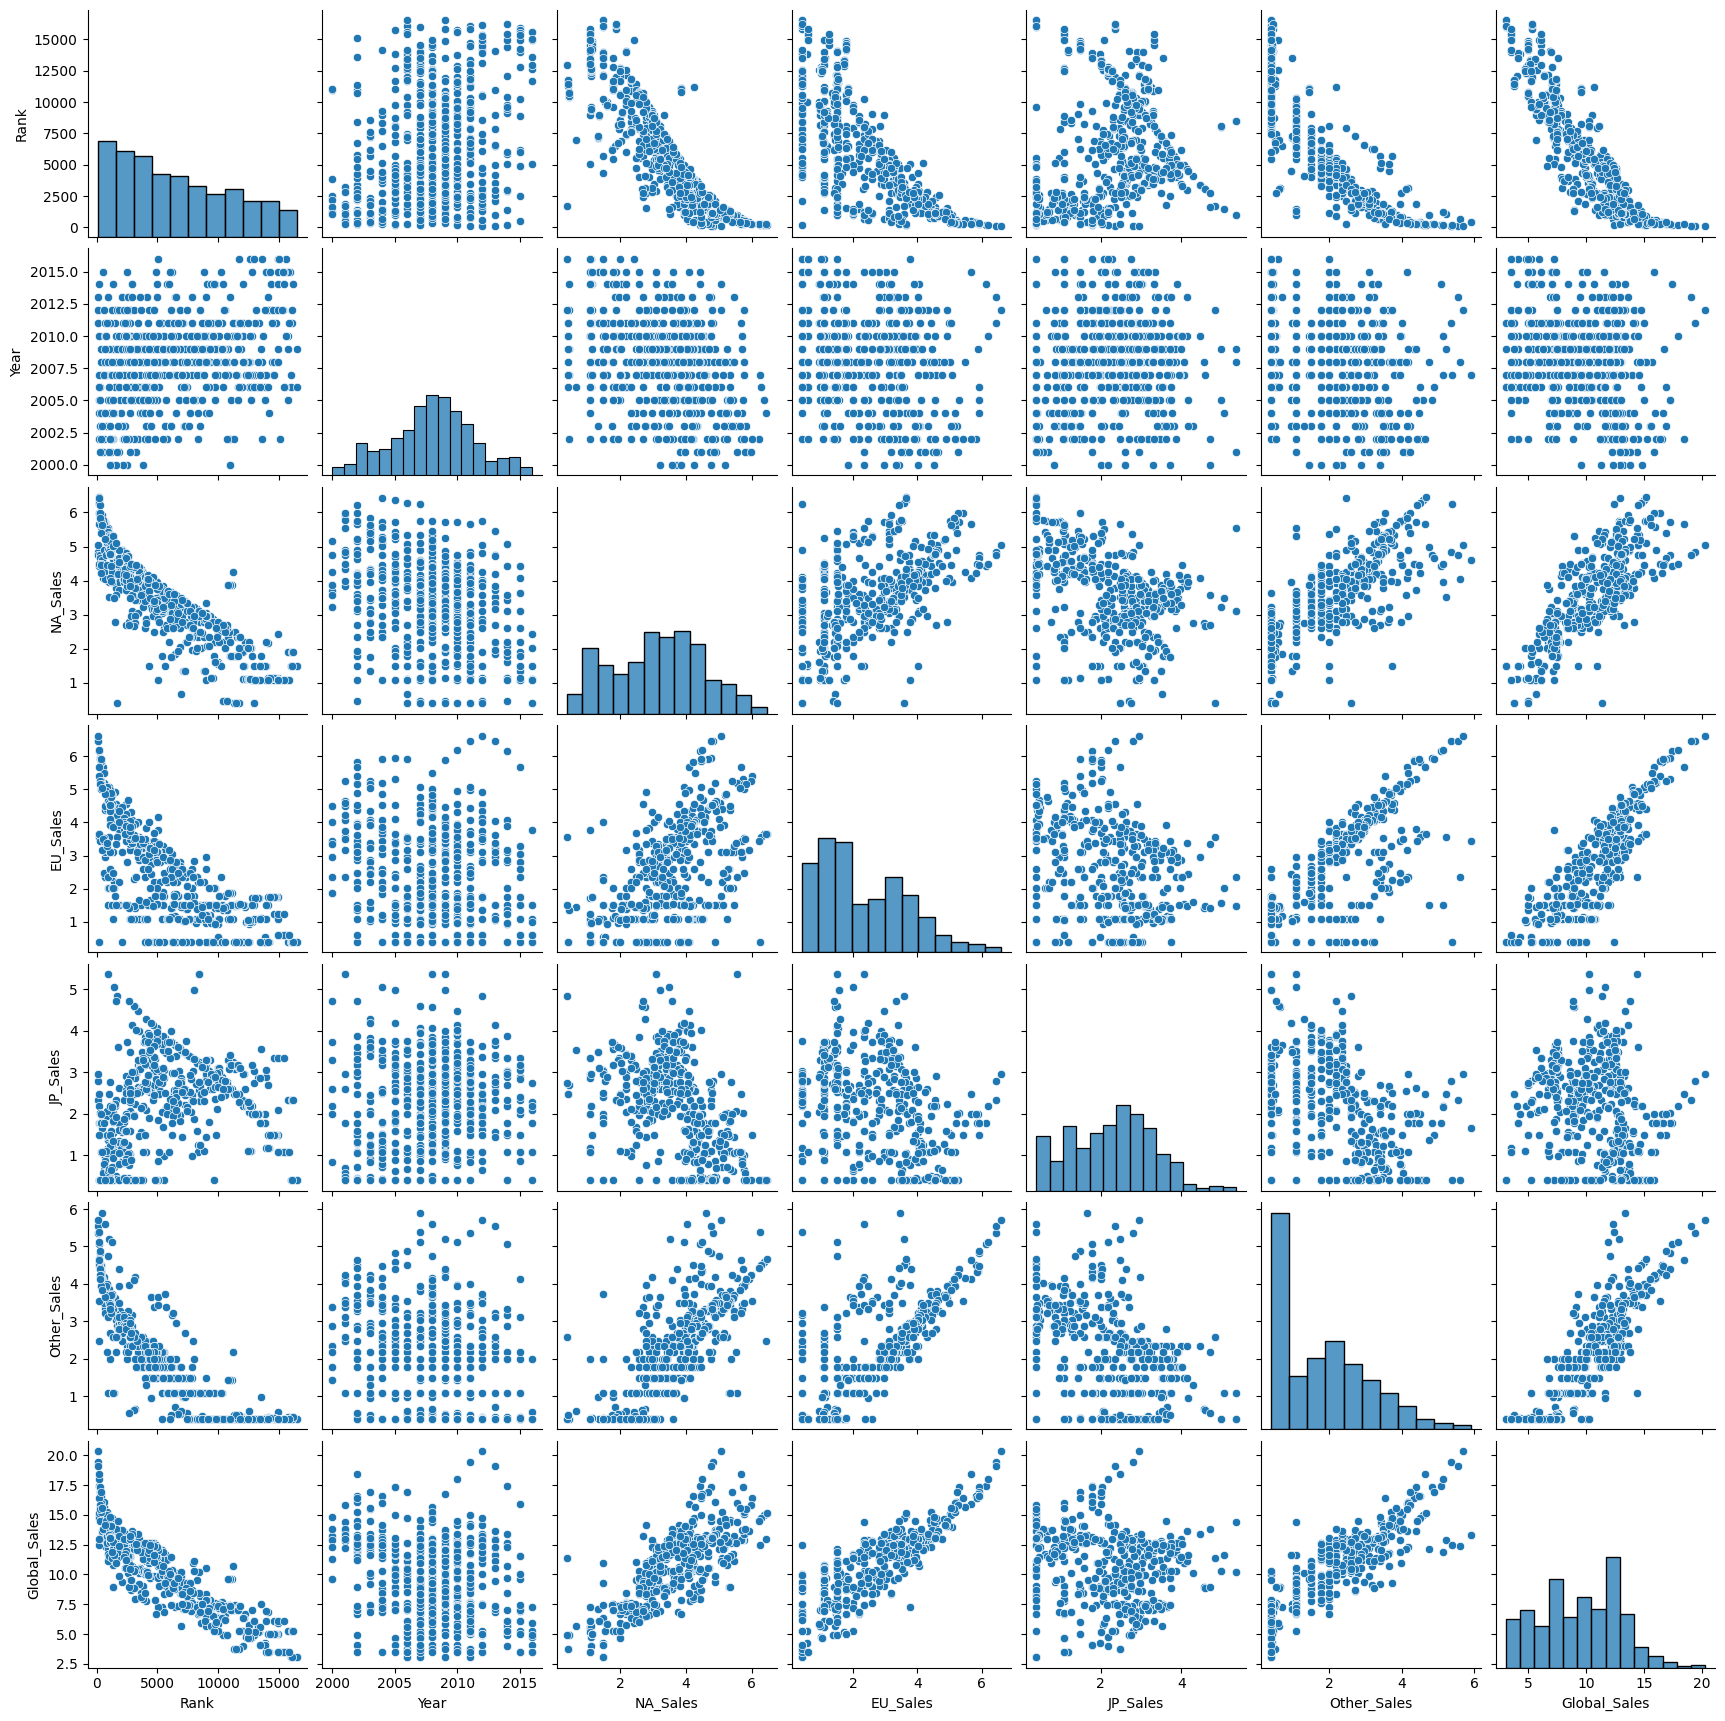

In [20]:
sns.pairplot(data=top3_data)

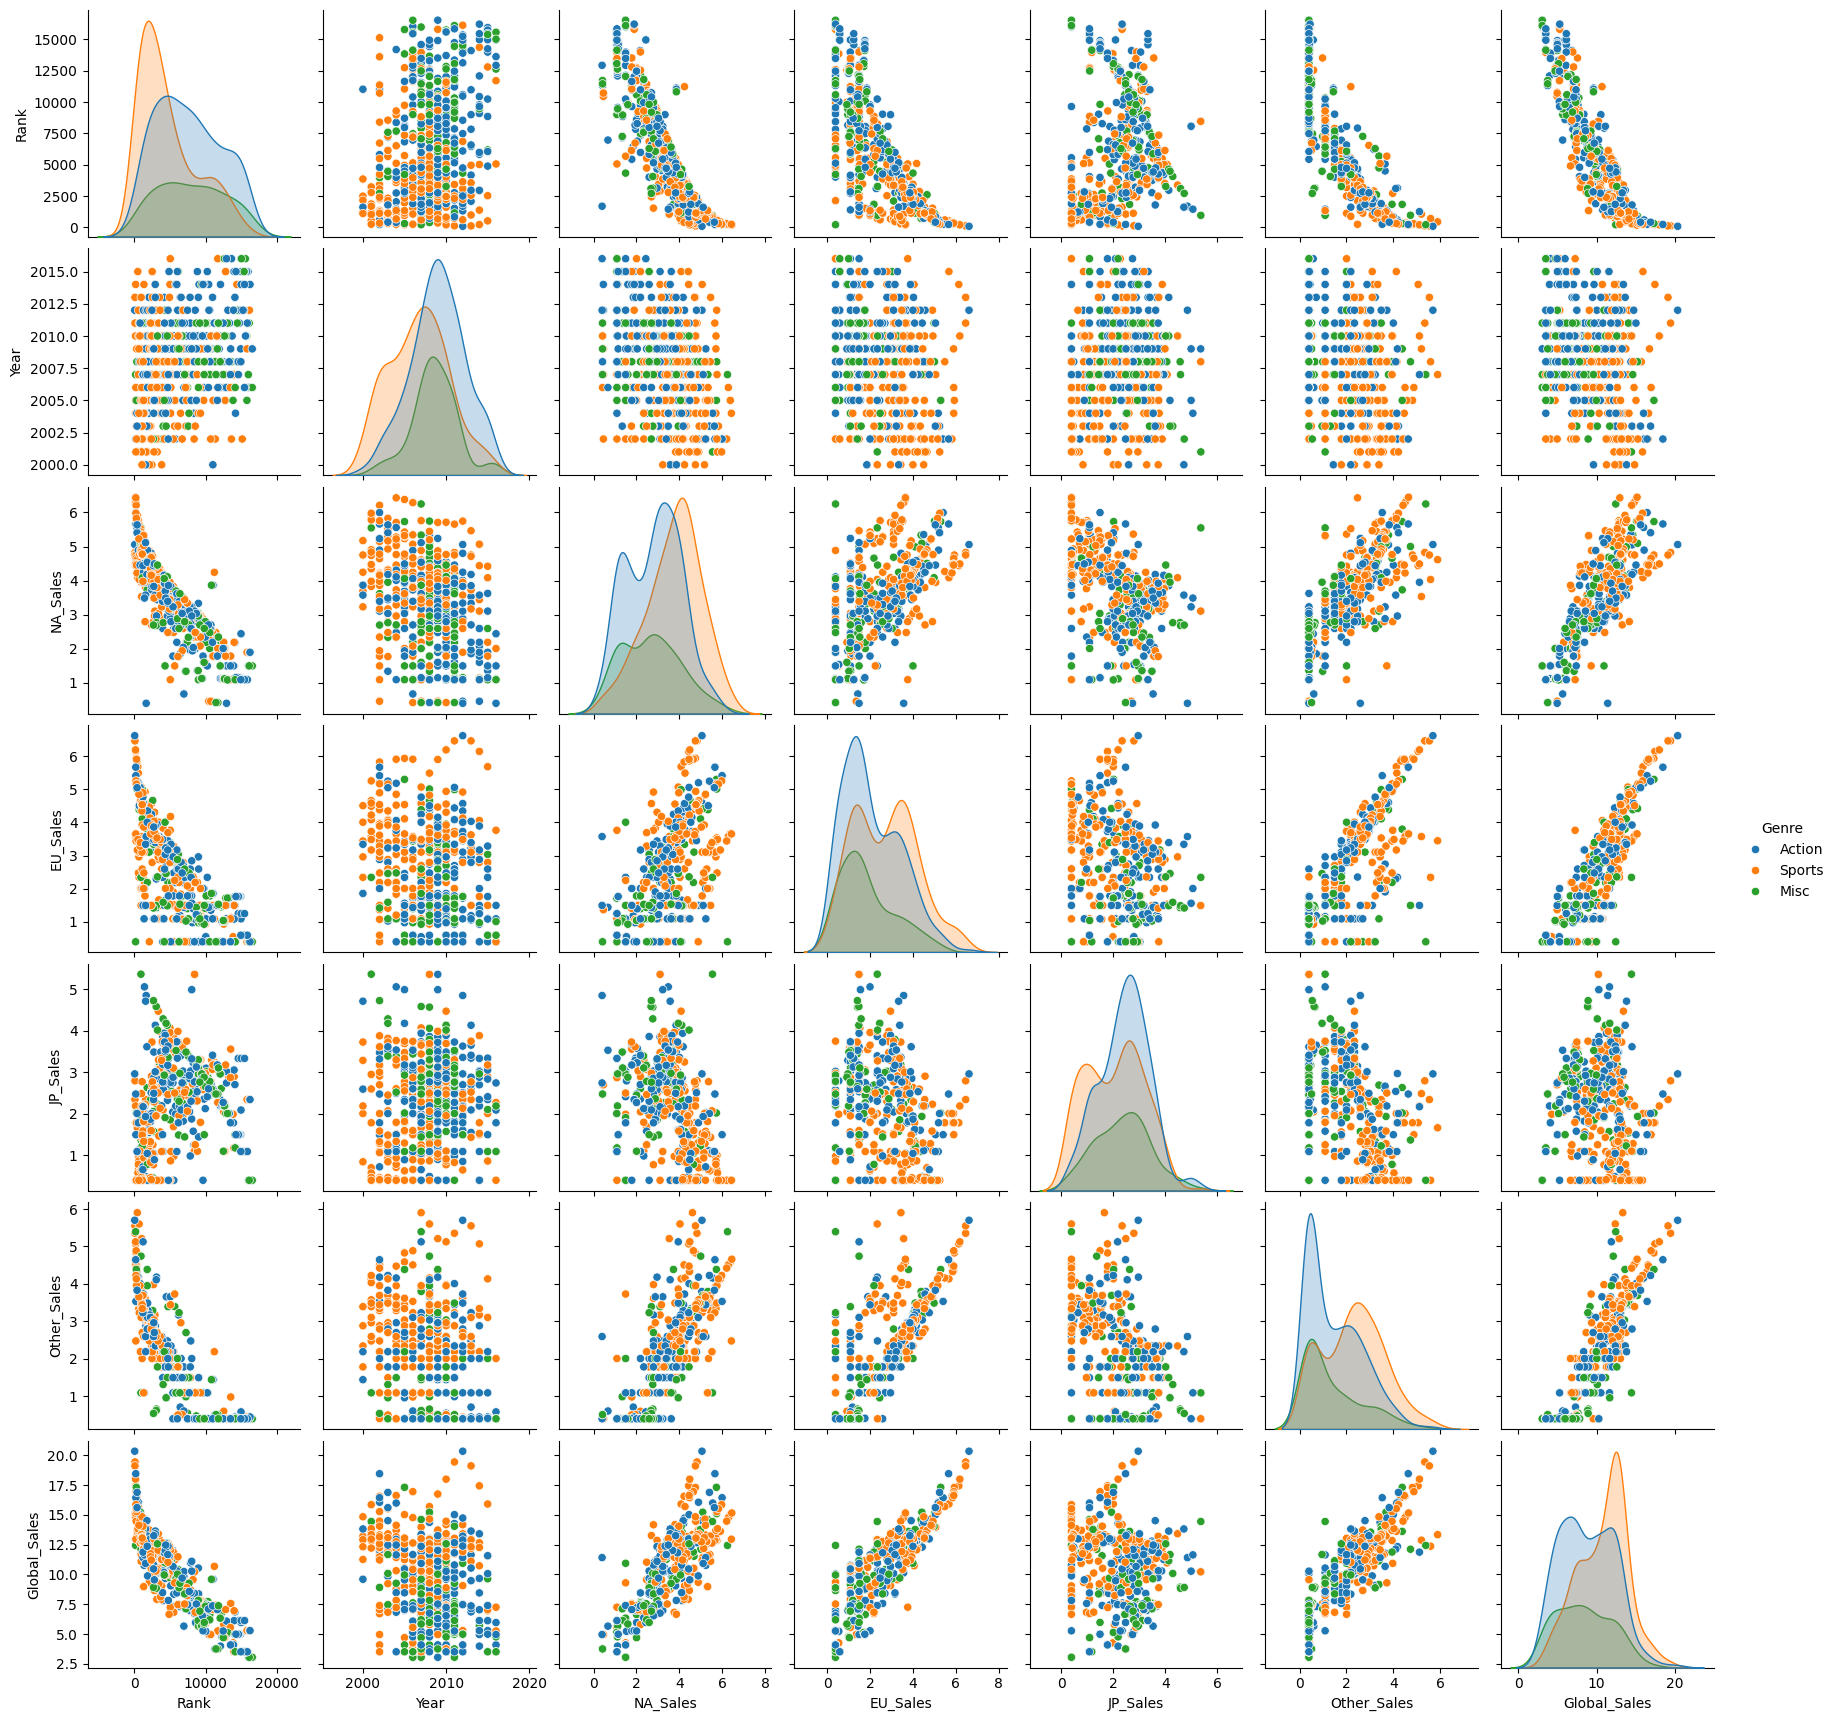

In [21]:
sns.pairplot(data=top3_data,hue="Genre",diag_kind="kde")